In [606]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [608]:
df=pd.read_csv("ecommerce_customer_data_large.csv")
df

,Customer ID,Purchase Date,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Customer Age,Returns,Customer Name,Age,Gender,Churn
0,44605,2023-05-03 21:30:02,Home,177,1,2427,PayPal,31,1.0,John Rivera,31,Female,0
1,44605,2021-05-16 13:57:44,Electronics,174,3,2448,PayPal,31,1.0,John Rivera,31,Female,0
2,44605,2020-07-13 06:16:57,Books,413,1,2345,Credit Card,31,1.0,John Rivera,31,Female,0
3,44605,2023-01-17 13:14:36,Electronics,396,3,937,Cash,31,0.0,John Rivera,31,Female,0
4,44605,2021-05-01 11:29:27,Books,259,4,2598,PayPal,31,1.0,John Rivera,31,Female,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
249995,33807,2023-01-24 12:32:18,Home,436,1,3664,Cash,63,0.0,Gabriel Williams,63,Male,0
249996,20455,2021-06-04 05:45:25,Electronics,233,1,4374,Credit Card,66,1.0,Barry Foster,66,Female,0
249997,28055,2022-11-10 17:11:57,Electronics,441,5,5296,Cash,63,NaN,Lisa Johnson,63,Female,0
249998,15023,2021-06-27 14:42:12,Electronics,44,2,2517,Cash,64,1.0,Melissa Fernandez,64,Male,0


In [609]:
df.head()

,Customer ID,Purchase Date,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Customer Age,Returns,Customer Name,Age,Gender,Churn
0,44605,2023-05-03 21:30:02,Home,177,1,2427,PayPal,31,1.0,John Rivera,31,Female,0
1,44605,2021-05-16 13:57:44,Electronics,174,3,2448,PayPal,31,1.0,John Rivera,31,Female,0
2,44605,2020-07-13 06:16:57,Books,413,1,2345,Credit Card,31,1.0,John Rivera,31,Female,0
3,44605,2023-01-17 13:14:36,Electronics,396,3,937,Cash,31,0.0,John Rivera,31,Female,0
4,44605,2021-05-01 11:29:27,Books,259,4,2598,PayPal,31,1.0,John Rivera,31,Female,0


In [610]:
df.tail()

,Customer ID,Purchase Date,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Customer Age,Returns,Customer Name,Age,Gender,Churn
249995,33807,2023-01-24 12:32:18,Home,436,1,3664,Cash,63,0.0,Gabriel Williams,63,Male,0
249996,20455,2021-06-04 05:45:25,Electronics,233,1,4374,Credit Card,66,1.0,Barry Foster,66,Female,0
249997,28055,2022-11-10 17:11:57,Electronics,441,5,5296,Cash,63,NaN,Lisa Johnson,63,Female,0
249998,15023,2021-06-27 14:42:12,Electronics,44,2,2517,Cash,64,1.0,Melissa Fernandez,64,Male,0
249999,4148,2020-09-07 05:12:19,Home,307,5,3634,Cash,32,0.0,Angela Norton,32,Male,0


In [611]:
df.shape

(250000, 13)

In [612]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Customer ID            250000 non-null  int64  
 1   Purchase Date          250000 non-null  object 
 2   Product Category       250000 non-null  object 
 3   Product Price          250000 non-null  int64  
 4   Quantity               250000 non-null  int64  
 5   Total Purchase Amount  250000 non-null  int64  
 6   Payment Method         250000 non-null  object 
 7   Customer Age           250000 non-null  int64  
 8   Returns                202618 non-null  float64
 9   Customer Name          250000 non-null  object 
 10  Age                    250000 non-null  int64  
 11  Gender                 250000 non-null  object 
 12  Churn                  250000 non-null  int64  
dtypes: float64(1), int64(7), object(5)
memory usage: 24.8+ MB


In [613]:
df.describe()

,Customer ID,Product Price,Quantity,Total Purchase Amount,Customer Age,Returns,Age,Churn
count,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,202618.000000,250000.000000,250000.00000
mean,25017.632092,254.742724,3.004936,2725.385196,43.798276,0.500824,43.798276,0.20052
std,14412.515718,141.738104,1.414737,1442.576095,15.364915,0.500001,15.364915,0.40039
min,1.000000,10.000000,1.000000,100.000000,18.000000,0.000000,18.000000,0.00000
25%,12590.000000,132.000000,2.000000,1476.000000,30.000000,0.000000,30.000000,0.00000
50%,25011.000000,255.000000,3.000000,2725.000000,44.000000,1.000000,44.000000,0.00000
75%,37441.250000,377.000000,4.000000,3975.000000,57.000000,1.000000,57.000000,0.00000
max,50000.000000,500.000000,5.000000,5350.000000,70.000000,1.000000,70.000000,1.00000


In [614]:
df.columns

Index(['Customer ID', 'Purchase Date', 'Product Category', 'Product Price',
       'Quantity', 'Total Purchase Amount', 'Payment Method', 'Customer Age',
       'Returns', 'Customer Name', 'Age', 'Gender', 'Churn'],
      dtype='object')

In [615]:
#Data Cleaning
df.columns=df.columns.str.lower()
df.columns=df.columns.str.replace(" ","_")

In [616]:
df.isnull().sum()

customer_id                  0
purchase_date                0
product_category             0
product_price                0
quantity                     0
total_purchase_amount        0
payment_method               0
customer_age                 0
returns                  47382
customer_name                0
age                          0
gender                       0
churn                        0
dtype: int64

In [617]:
df['returns'].value_counts(dropna=False)

returns
1.0    101476
0.0    101142
NaN     47382
Name: count, dtype: int64

In [618]:
df['returns']=df['returns'].fillna('No')


In [619]:
df.isnull().sum()

customer_id              0
purchase_date            0
product_category         0
product_price            0
quantity                 0
total_purchase_amount    0
payment_method           0
customer_age             0
returns                  0
customer_name            0
age                      0
gender                   0
churn                    0
dtype: int64

In [632]:
df.duplicated().sum()

0

In [634]:
df['gender'].unique()

array(['Female', 'Male'], dtype=object)

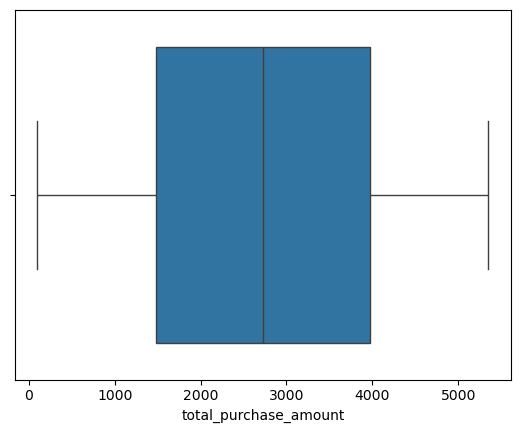

In [636]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=df['total_purchase_amount'])
plt.show()

In [638]:
##does not contain outliers.

In [640]:
df['purchase_date'] = pd.to_datetime(df['purchase_date'])

In [642]:
df['purchase_date']

0        2023-05-03 21:30:02
1        2021-05-16 13:57:44
2        2020-07-13 06:16:57
3        2023-01-17 13:14:36
4        2021-05-01 11:29:27
                 ...        
249995   2023-01-24 12:32:18
249996   2021-06-04 05:45:25
249997   2022-11-10 17:11:57
249998   2021-06-27 14:42:12
249999   2020-09-07 05:12:19
Name: purchase_date, Length: 250000, dtype: datetime64[ns]

In [644]:
df

,customer_id,purchase_date,product_category,product_price,quantity,total_purchase_amount,payment_method,customer_age,returns,customer_name,age,gender,churn
0,44605,2023-05-03 21:30:02,Home,177,1,2427,PayPal,31,1.0,John Rivera,31,Female,0
1,44605,2021-05-16 13:57:44,Electronics,174,3,2448,PayPal,31,1.0,John Rivera,31,Female,0
2,44605,2020-07-13 06:16:57,Books,413,1,2345,Credit Card,31,1.0,John Rivera,31,Female,0
3,44605,2023-01-17 13:14:36,Electronics,396,3,937,Cash,31,0.0,John Rivera,31,Female,0
4,44605,2021-05-01 11:29:27,Books,259,4,2598,PayPal,31,1.0,John Rivera,31,Female,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
249995,33807,2023-01-24 12:32:18,Home,436,1,3664,Cash,63,0.0,Gabriel Williams,63,Male,0
249996,20455,2021-06-04 05:45:25,Electronics,233,1,4374,Credit Card,66,1.0,Barry Foster,66,Female,0
249997,28055,2022-11-10 17:11:57,Electronics,441,5,5296,Cash,63,No,Lisa Johnson,63,Female,0
249998,15023,2021-06-27 14:42:12,Electronics,44,2,2517,Cash,64,1.0,Melissa Fernandez,64,Male,0


In [646]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   customer_id            250000 non-null  int64         
 1   purchase_date          250000 non-null  datetime64[ns]
 2   product_category       250000 non-null  object        
 3   product_price          250000 non-null  int64         
 4   quantity               250000 non-null  int64         
 5   total_purchase_amount  250000 non-null  int64         
 6   payment_method         250000 non-null  object        
 7   customer_age           250000 non-null  int64         
 8   returns                250000 non-null  object        
 9   customer_name          250000 non-null  object        
 10  age                    250000 non-null  int64         
 11  gender                 250000 non-null  object        
 12  churn                  250000 non-null  int6

# feature Engineering

In [649]:
df['purchase_year'] = df['purchase_date'].dt.year
df['purchase_month'] = df['purchase_date'].dt.month
df['purchase_day'] = df['purchase_date'].dt.day
df['purchase_quater'] = df['purchase_date'].dt.quarter

In [651]:
df

,customer_id,purchase_date,product_category,product_price,quantity,total_purchase_amount,payment_method,customer_age,returns,customer_name,age,gender,churn,purchase_year,purchase_month,purchase_day,purchase_quater
0,44605,2023-05-03 21:30:02,Home,177,1,2427,PayPal,31,1.0,John Rivera,31,Female,0,2023,5,3,2
1,44605,2021-05-16 13:57:44,Electronics,174,3,2448,PayPal,31,1.0,John Rivera,31,Female,0,2021,5,16,2
2,44605,2020-07-13 06:16:57,Books,413,1,2345,Credit Card,31,1.0,John Rivera,31,Female,0,2020,7,13,3
3,44605,2023-01-17 13:14:36,Electronics,396,3,937,Cash,31,0.0,John Rivera,31,Female,0,2023,1,17,1
4,44605,2021-05-01 11:29:27,Books,259,4,2598,PayPal,31,1.0,John Rivera,31,Female,0,2021,5,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
249995,33807,2023-01-24 12:32:18,Home,436,1,3664,Cash,63,0.0,Gabriel Williams,63,Male,0,2023,1,24,1
249996,20455,2021-06-04 05:45:25,Electronics,233,1,4374,Credit Card,66,1.0,Barry Foster,66,Female,0,2021,6,4,2
249997,28055,2022-11-10 17:11:57,Electronics,441,5,5296,Cash,63,No,Lisa Johnson,63,Female,0,2022,11,10,4
249998,15023,2021-06-27 14:42:12,Electronics,44,2,2517,Cash,64,1.0,Melissa Fernandez,64,Male,0,2021,6,27,2


In [653]:
# age_group

df["age_group"]=pd.cut(
    df['age'],
    bins=[18,25,35,45,65,100],
    labels=['18-25','26-35','36-45','46-60','60+']
  )

In [655]:
#spending level
df['spending level']=pd.qcut(
    df['total_purchase_amount'],
    q=3,
    labels=['LOW','MEDIUM','HIGH']
    
)

In [657]:
df['price_category'] = pd.cut(
    df['product_price'],
    bins=3,
    labels=['Low Price','Medium Price','High Price']
)

In [659]:
df['quantity_category'] = pd.cut(
    df['quantity'],
    bins=[0,2,5,10],
    labels=['Low','Medium','High']
)

In [661]:
df

,customer_id,purchase_date,product_category,product_price,quantity,total_purchase_amount,payment_method,customer_age,returns,customer_name,...,gender,churn,purchase_year,purchase_month,purchase_day,purchase_quater,age_group,spending level,price_category,quantity_category
0,44605,2023-05-03 21:30:02,Home,177,1,2427,PayPal,31,1.0,John Rivera,...,Female,0,2023,5,3,2,26-35,MEDIUM,Medium Price,Low
1,44605,2021-05-16 13:57:44,Electronics,174,3,2448,PayPal,31,1.0,John Rivera,...,Female,0,2021,5,16,2,26-35,MEDIUM,Medium Price,Medium
2,44605,2020-07-13 06:16:57,Books,413,1,2345,Credit Card,31,1.0,John Rivera,...,Female,0,2020,7,13,3,26-35,MEDIUM,High Price,Low
3,44605,2023-01-17 13:14:36,Electronics,396,3,937,Cash,31,0.0,John Rivera,...,Female,0,2023,1,17,1,26-35,LOW,High Price,Medium
4,44605,2021-05-01 11:29:27,Books,259,4,2598,PayPal,31,1.0,John Rivera,...,Female,0,2021,5,1,2,26-35,MEDIUM,Medium Price,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
249995,33807,2023-01-24 12:32:18,Home,436,1,3664,Cash,63,0.0,Gabriel Williams,...,Male,0,2023,1,24,1,46-60,HIGH,High Price,Low
249996,20455,2021-06-04 05:45:25,Electronics,233,1,4374,Credit Card,66,1.0,Barry Foster,...,Female,0,2021,6,4,2,60+,HIGH,Medium Price,Low
249997,28055,2022-11-10 17:11:57,Electronics,441,5,5296,Cash,63,No,Lisa Johnson,...,Female,0,2022,11,10,4,46-60,HIGH,High Price,Medium
249998,15023,2021-06-27 14:42:12,Electronics,44,2,2517,Cash,64,1.0,Melissa Fernandez,...,Male,0,2021,6,27,2,46-60,MEDIUM,Low Price,Low


# EDA

In [664]:
# ==========================
# Key Performance Indicators
# ==========================

total_revenue = df['total_purchase_amount'].sum()
average_purchase = df['total_purchase_amount'].mean()
total_customers = df['customer_id'].nunique()
total_orders = len(df)
maximum_purchase = df['total_purchase_amount'].max()
minimum_purchase = df['total_purchase_amount'].min()

print(f"Total Revenue          : {total_revenue:,.2f}")
print(f"Average Purchase       : {average_purchase:.2f}")
print(f"Total Customers        : {total_customers:,}")
print(f"Total Orders           : {total_orders:,}")
print(f"Maximum Purchase       : {maximum_purchase:,.2f}")
print(f"Minimum Purchase       : {minimum_purchase:,.2f}")

Total Revenue          : 681,346,299.00
Average Purchase       : 2725.39
Total Customers        : 49,661
Total Orders           : 250,000
Maximum Purchase       : 5,350.00
Minimum Purchase       : 100.00


In [667]:
df.groupby('product_category')['total_purchase_amount'].agg(['count','sum','mean']).sort_values(by='sum',ascending=False)

,count,sum,mean
product_category,,,
Home,62542,171138916,2736.383806
Clothing,62581,170716122,2727.922564
Electronics,62630,170146025,2716.685694
Books,62247,169345236,2720.536508


In [669]:
df['payment_method'].value_counts()

payment_method
Credit Card    83547
PayPal         83441
Cash           83012
Name: count, dtype: int64

In [671]:
df['gender'].value_counts()

gender
Male      125676
Female    124324
Name: count, dtype: int64

In [673]:
df['churn'].value_counts()

churn
0    199870
1     50130
Name: count, dtype: int64

In [675]:
df.groupby('gender')['total_purchase_amount'].mean()

gender
Female    2723.202728
Male      2727.544185
Name: total_purchase_amount, dtype: float64

In [677]:
df.groupby('age_group')['total_purchase_amount'].mean()

C:\Users\MSI-1\AppData\Local\Temp\ipykernel_9728\3141924176.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('age_group')['total_purchase_amount'].mean()


age_group
18-25    2605.197134
26-35    2664.074852
36-45    2700.942232
46-60    2788.594785
60+      2846.632023
Name: total_purchase_amount, dtype: float64

In [679]:
df.groupby('purchase_month')['total_purchase_amount'].sum()

purchase_month
1     62201958
2     57050354
3     62355745
4     60217450
5     62533980
6     60286066
7     62587751
8     63063912
9     51763012
10    46595245
11    45604668
12    47086158
Name: total_purchase_amount, dtype: int64

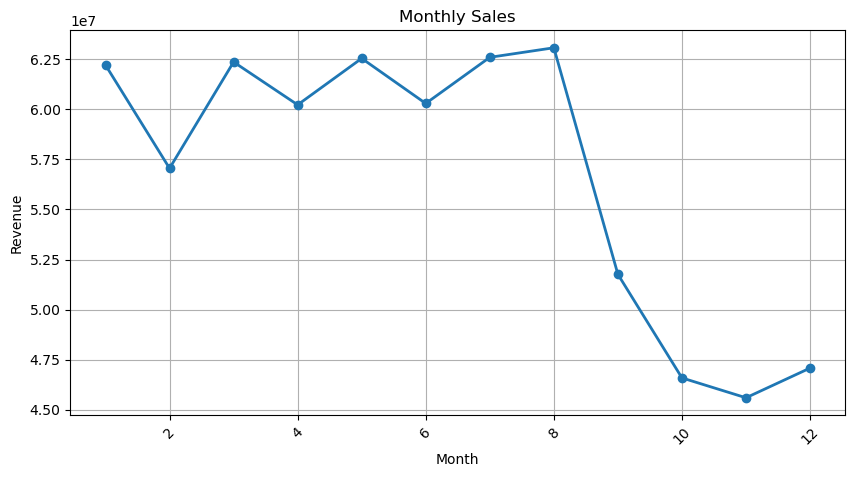

In [682]:
monthly_sales = df.groupby('purchase_month')['total_purchase_amount'].sum()

plt.figure(figsize=(10,5))
plt.plot(monthly_sales.index,
         monthly_sales.values,
         marker='o',
         linewidth=2)

plt.title("Monthly Sales")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

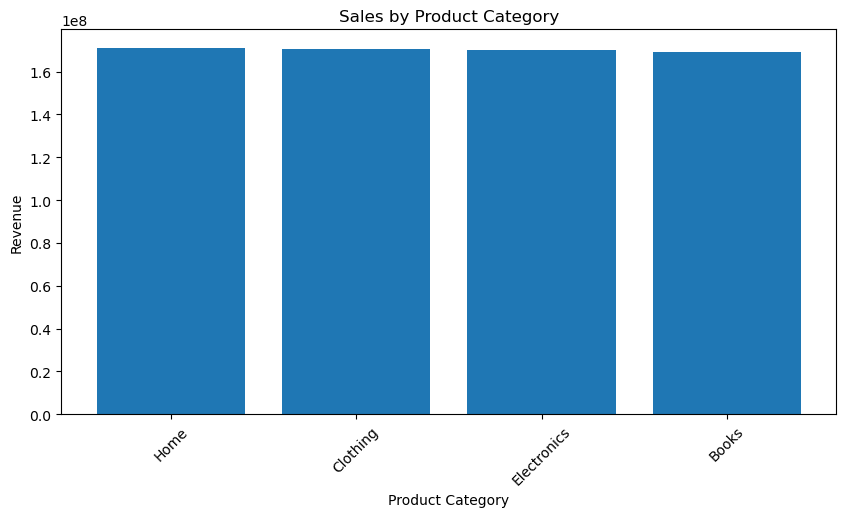

In [684]:
category_sales = df.groupby('product_category')['total_purchase_amount'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))
plt.bar(category_sales.index,
        category_sales.values)

plt.title("Sales by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

plt.show()

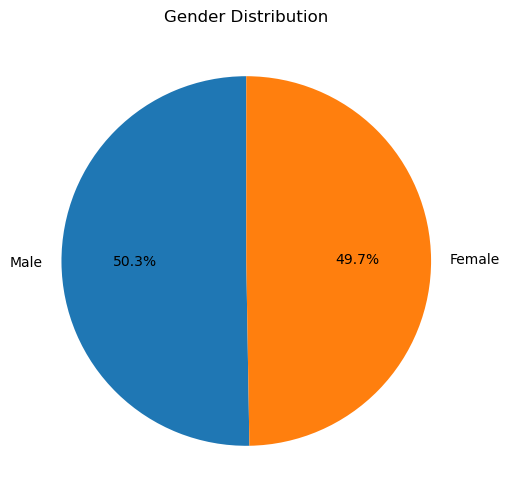

In [686]:
gender = df['gender'].value_counts()

plt.figure(figsize=(6,6))

plt.pie(gender,
        labels=gender.index,
        autopct='%1.1f%%',
        startangle=90)

plt.title("Gender Distribution")

plt.show()

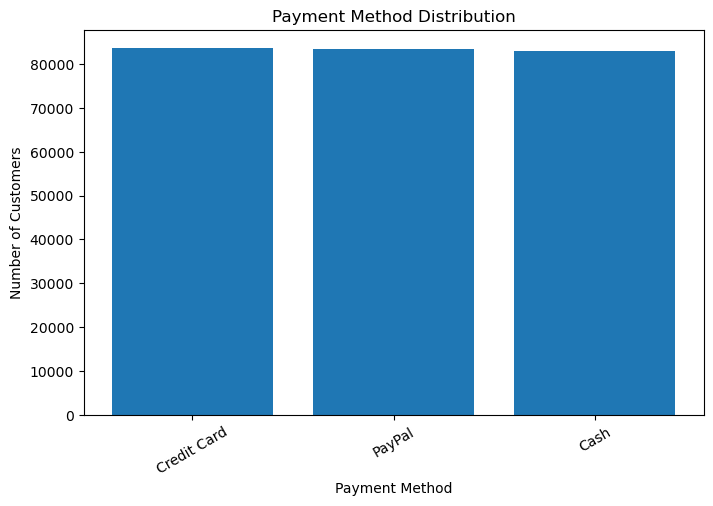

In [688]:
payment = df['payment_method'].value_counts()

plt.figure(figsize=(8,5))

plt.bar(payment.index,
        payment.values)

plt.title("Payment Method Distribution")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")

plt.xticks(rotation=30)

plt.show()

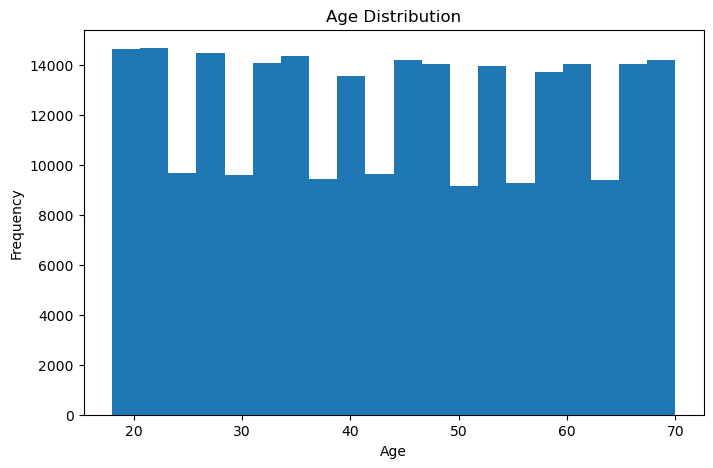

In [690]:
plt.figure(figsize=(8,5))

plt.hist(df['age'],
         bins=20)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

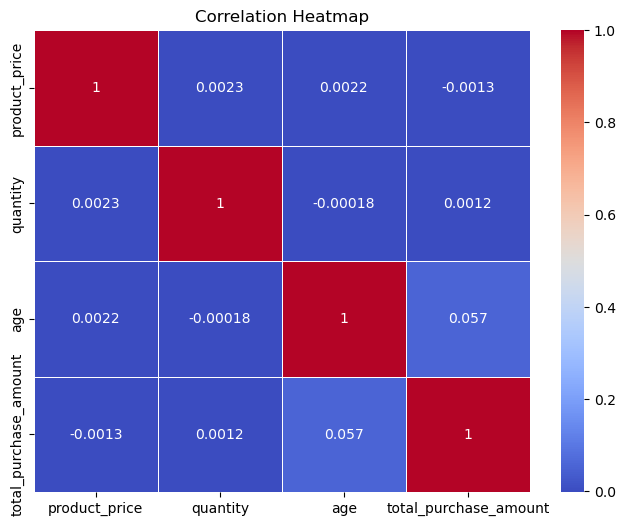

In [692]:
numeric_columns = ['product_price',
                   'quantity',
                   'age',
                   'total_purchase_amount']

corr = df[numeric_columns].corr()

plt.figure(figsize=(8,6))

sns.heatmap(corr,
            annot=True,
            cmap='coolwarm',
            linewidths=0.5)

plt.title("Correlation Heatmap")

plt.show()

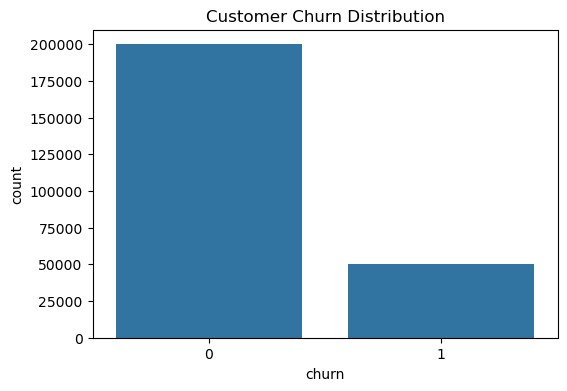

In [694]:
plt.figure(figsize=(6,4))

sns.countplot(x='churn',
              data=df)

plt.title("Customer Churn Distribution")

plt.show()

C:\Users\MSI-1\AppData\Local\Temp\ipykernel_9728\1477783569.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sales = df.groupby('age_group')['total_purchase_amount'].sum()


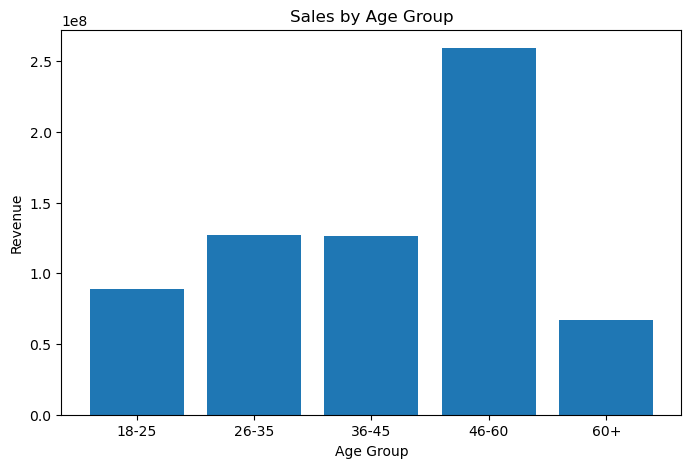

In [696]:
sales = df.groupby('age_group')['total_purchase_amount'].sum()

plt.figure(figsize=(8,5))

plt.bar(sales.index,
        sales.values)

plt.title("Sales by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Revenue")

plt.show()

# ├── Customer Segmentation (K-Means)


In [699]:
#---------->>>>>>>>Select Features<<<<<<<<<<<<<---------------------
features = df[['age',
               'product_price',
               'quantity',
               'total_purchase_amount']]

In [701]:
# ===========Standardize the Data=========================================
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_data = scaler.fit_transform(features)

#===========Find the Best Number of Clusters (Elbow Method)=================

from sklearn.cluster import KMeans

wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i,
                    random_state=42)

    kmeans.fit(scaled_data)

    wcss.append(kmeans.inertia_)

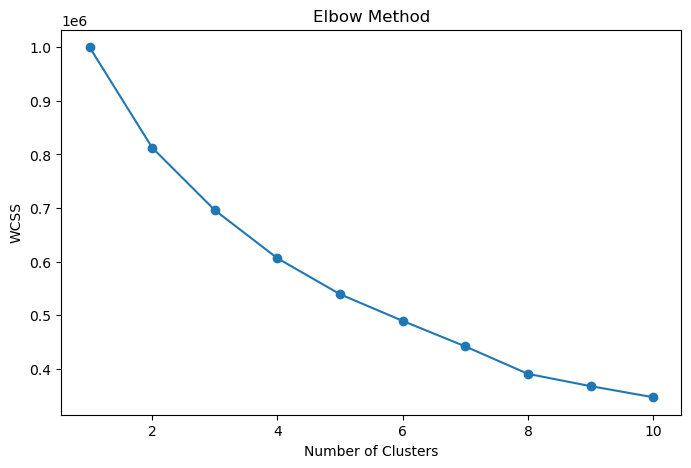

In [702]:
#=================plot========================================================
plt.figure(figsize=(8,5))

plt.plot(range(1,11),
         wcss,
         marker='o')

plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

plt.title("Elbow Method")

plt.show()

In [703]:
#=================Train K-Means============================
kmeans = KMeans(n_clusters=4,
                random_state=42)

df['customer_segment'] = kmeans.fit_predict(scaled_data)

In [704]:
df[['customer_id',
    'customer_segment']].head()

,customer_id,customer_segment
0,44605,3
1,44605,3
2,44605,2
3,44605,0
4,44605,1


In [709]:
#============Number of Customers in Each Segment=================
df['customer_segment'].value_counts()

customer_segment
1    62867
2    62851
0    62173
3    62109
Name: count, dtype: int64

In [711]:
#===============Analyse each segment==============================
df.groupby('customer_segment')[['age',
                                'product_price',
                                'quantity',
                                'total_purchase_amount']].mean()

,age,product_price,quantity,total_purchase_amount
customer_segment,,,,
0,42.128963,386.895324,3.372219,1584.384283
1,45.360873,216.154485,4.307140,3880.262650
2,45.891442,291.109099,1.689011,3859.173140
3,41.769470,124.712296,2.650824,1551.256855


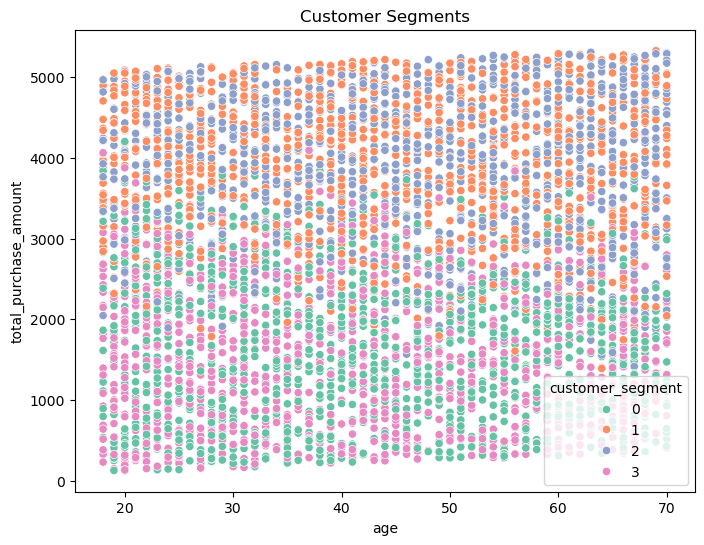

In [713]:
#================Visualize the Clusters===================

sample_df = df.sample(5000, random_state=42)

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=sample_df,
    x='age',
    y='total_purchase_amount',
    hue='customer_segment',
    palette='Set2'
)

plt.title("Customer Segments")
plt.show()

In [715]:
#You can describe the segments like this (adapt to your actual results):
#Segment Description of Above graph
#0	Young, low-spending customers
#1	High-value customers with high purchase amounts
#2	Medium-spending regular customers
#3	Older customers with high quantities purchased

In [717]:
#connect data se to pgAdmin4

In [724]:
import pandas as pd
from sqlalchemy import create_engine

# Read CSV
#df = pd.read_csv("ecommerce_customer_data_large.csv")

# Rename columns
#df.columns = df.columns.str.lower()
#df.columns = df.columns.str.replace(' ', '_')
#df = df.rename(columns={'purchase_amount_(usd)': 'purchase_amount'})

# Check column names
print(df.columns.tolist())

# PostgreSQL connection
username = "postgres"
password = "9262"
host = "localhost"
port = "5432"
database = "Customer Behavior 2"

engine = create_engine(
    f"postgresql+psycopg2://{username}:{password}@{host}:{port}/{database}"
)

# Upload to PostgreSQL
df.to_sql("customer", engine, if_exists="replace", index=False)

print("Data loaded successfully!")

['customer_id', 'purchase_date', 'product_category', 'product_price', 'quantity', 'total_purchase_amount', 'payment_method', 'customer_age', 'returns', 'customer_name', 'age', 'gender', 'churn', 'purchase_year', 'purchase_month', 'purchase_day', 'purchase_quater', 'age_group', 'spending level', 'price_category', 'quantity_category', 'customer_segment']
Data loaded successfully!


In [721]:
df

,customer_id,purchase_date,product_category,product_price,quantity,total_purchase_amount,payment_method,customer_age,returns,customer_name,...,churn,purchase_year,purchase_month,purchase_day,purchase_quater,age_group,spending level,price_category,quantity_category,customer_segment
0,44605,2023-05-03 21:30:02,Home,177,1,2427,PayPal,31,1.0,John Rivera,...,0,2023,5,3,2,26-35,MEDIUM,Medium Price,Low,3
1,44605,2021-05-16 13:57:44,Electronics,174,3,2448,PayPal,31,1.0,John Rivera,...,0,2021,5,16,2,26-35,MEDIUM,Medium Price,Medium,3
2,44605,2020-07-13 06:16:57,Books,413,1,2345,Credit Card,31,1.0,John Rivera,...,0,2020,7,13,3,26-35,MEDIUM,High Price,Low,2
3,44605,2023-01-17 13:14:36,Electronics,396,3,937,Cash,31,0.0,John Rivera,...,0,2023,1,17,1,26-35,LOW,High Price,Medium,0
4,44605,2021-05-01 11:29:27,Books,259,4,2598,PayPal,31,1.0,John Rivera,...,0,2021,5,1,2,26-35,MEDIUM,Medium Price,Medium,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
249995,33807,2023-01-24 12:32:18,Home,436,1,3664,Cash,63,0.0,Gabriel Williams,...,0,2023,1,24,1,46-60,HIGH,High Price,Low,2
249996,20455,2021-06-04 05:45:25,Electronics,233,1,4374,Credit Card,66,1.0,Barry Foster,...,0,2021,6,4,2,60+,HIGH,Medium Price,Low,2
249997,28055,2022-11-10 17:11:57,Electronics,441,5,5296,Cash,63,No,Lisa Johnson,...,0,2022,11,10,4,46-60,HIGH,High Price,Medium,1
249998,15023,2021-06-27 14:42:12,Electronics,44,2,2517,Cash,64,1.0,Melissa Fernandez,...,0,2021,6,27,2,46-60,MEDIUM,Low Price,Low,3
